# A. Neuron semantic atlas via input-projection columns

The encoder's first layer is `LayerNorm(N_neurons) → Linear(N_neurons → d_model)`. The i-th column of `input_proj.weight` is neuron i's direction in the d_model latent space. We propagate that direction through the rest of the frozen network to obtain each neuron's implied SigLIP direction (1152-d), then score it against named semantic axes.

**Caveat:** this reads off the linear contribution of each neuron; nonlinear interactions through the transformer are not captured. LayerNorm is handled by using a probe input with one neuron active at a time (post-LN effective direction), not the raw weight column.

**Output:** per-neuron semantic label + brain-area map — which areas house animacy-coding, face-coding, vehicle-coding neurons.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter

sys.path.insert(0, '.')
from config_const import SEED, HVM_SIGLIP_EMBEDDINGS_PATH, HVM_CATEGORIES, HVM_N_VAR
from data_utils.hvm_loader import _load_hvm_neural, _category_stratified_split, get_neuron_map
from encoders.multihead import MultiHeadTransformer
from get_device import get_device

DEVICE = get_device()

In [2]:
# Load encoder
cfg = json.load(open('cache/best_hvm_multihead_config.json'))
ckpt = torch.load(cfg['checkpoint'], weights_only=False, map_location='cpu')

rsp, dead_mask, monkey_sessions = _load_hvm_neural(area='all')
N_neurons = rsp.shape[1]
T = rsp.shape[2]

model = MultiHeadTransformer(
    n_neurons=N_neurons, d_model=cfg['d_model'], n_heads=cfg['n_heads'],
    n_layers=cfg['n_layers'], shared_dim=cfg['shared_dim'],
    dropout=cfg['dropout'], n_categories=10,
)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Encoder loaded. N_neurons={N_neurons}, d_model={cfg["d_model"]}')

Loading HVM sessions: 100%|██████████| 10/10 [00:41<00:00,  4.12s/it]


Encoder loaded. N_neurons=2330, d_model=64


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
# Build neuron → brain area map
neuron_map = get_neuron_map(dead_mask, monkey_sessions)
areas = [e['area'] for e in neuron_map]
print(f'Neuron map: {len(neuron_map)} neurons')
from collections import Counter
print(Counter(areas))

Neuron map: 2330 neurons
Counter({'TE0': 664, 'TE3': 565, 'unknown': 430, 'TE2': 381, 'PHC': 129, 'WM': 94, 'HC': 53, 'PRH': 14})


## 1. Compute per-neuron implied SigLIP direction

For each neuron i, construct a probe input where only neuron i fires (amplitude = 1 σ, constant across time bins), run it through the frozen encoder, and record the resulting SigLIP embedding. This captures the post-LayerNorm effective direction including any nonlinear gain from the transformer, while isolating individual neuron contributions.

In [4]:
# Estimate per-neuron firing std from the full dataset (for probe amplitude scaling)
neuron_std = rsp.std(axis=(0, 2))  # (N_neurons,)
neuron_std = np.where(neuron_std == 0, 1.0, neuron_std)

BATCH = 64  # neurons per forward pass
neuron_siglip = []  # will be (N_neurons, 1152)

# Use category 0 (apple, inanimate) as a neutral category for all probes
# so category embedding doesn't introduce a bias toward any semantic axis
CAT_PROBE = 0

with torch.no_grad():
    for start in range(0, N_neurons, BATCH):
        end = min(start + BATCH, N_neurons)
        B = end - start

        # Probe: neuron i fires at its own std, all others silent
        # Shape: (B, T, N_neurons) — each item in batch is one neuron's probe
        x = torch.zeros(B, T, N_neurons)
        for j in range(B):
            ni = start + j
            x[j, :, ni] = float(neuron_std[ni])

        cat = torch.full((B,), CAT_PROBE, dtype=torch.long)
        out = model(x, cat=cat)['siglip']  # (B, 1152)
        neuron_siglip.append(out.cpu().numpy())

        if (start // BATCH) % 20 == 0:
            print(f'  neurons {start}-{end-1}/{N_neurons}')

neuron_siglip = np.concatenate(neuron_siglip, axis=0)  # (N_neurons, 1152)
print(f'neuron_siglip: {neuron_siglip.shape}')

  neurons 0-63/2330
  neurons 1280-1343/2330
neuron_siglip: (2330, 1152)


## 2. Define semantic axes from category-mean SigLIP embeddings

In [5]:
siglip_all = torch.load(HVM_SIGLIP_EMBEDDINGS_PATH, weights_only=True).float()
gt_all = F.normalize(siglip_all, dim=-1).numpy()  # (450, 1152)
cat_all = np.arange(450) // HVM_N_VAR

cat_means = np.stack([
    gt_all[cat_all == c].mean(axis=0) for c in range(10)
])  # (10, 1152)
cat_means /= np.linalg.norm(cat_means, axis=1, keepdims=True)

# HVM_CATEGORIES = ('apple','bear','car','chair','dog','elephant','head','plane','table','turtle')
animate   = [1, 4, 5, 6, 9]   # bear, dog, elephant, head, turtle
inanimate = [0, 2, 3, 7, 8]   # apple, car, chair, plane, table

def axis(pos_ids, neg_ids):
    v = cat_means[pos_ids].mean(axis=0) - cat_means[neg_ids].mean(axis=0)
    return v / (np.linalg.norm(v) + 1e-12)

AXES = {
    'Animacy':      axis([1,4,5,6,9], [0,2,3,7,8]),
    'Face-ness':    axis([6], [0,1,2,3,4,5,7,8,9]),
    'Vehicle-ness': axis([2,7], [0,1,3,4,5,6,8,9]),
    'Furniture':    axis([3,8], [0,1,2,4,5,6,7,9]),
    'Roundness':    axis([0,1,4,5,9], [2,3,7,8]),
}

print('Axes:', list(AXES.keys()))

Axes: ['Animacy', 'Face-ness', 'Vehicle-ness', 'Furniture', 'Roundness']


In [6]:
# Per-neuron score on each axis: dot product of neuron's SigLIP direction with axis vector
# neuron_siglip is already L2-normalised (output of F.normalize in model)
scores = {}  # axis_name -> (N_neurons,)
for name, vec in AXES.items():
    scores[name] = neuron_siglip @ vec  # cosine similarity (both unit vectors)

score_matrix = np.stack(list(scores.values()), axis=1)  # (N_neurons, n_axes)
axis_names = list(AXES.keys())

# Assign each neuron its top axis (highest |score|)
top_axis_idx = np.argmax(np.abs(score_matrix), axis=1)  # (N_neurons,)
top_axis_labels = [axis_names[i] for i in top_axis_idx]
print('Top-axis distribution:')
print(Counter(top_axis_labels))

Top-axis distribution:
Counter({'Vehicle-ness': 803, 'Animacy': 565, 'Face-ness': 555, 'Roundness': 259, 'Furniture': 148})


## 3. Score distributions per axis

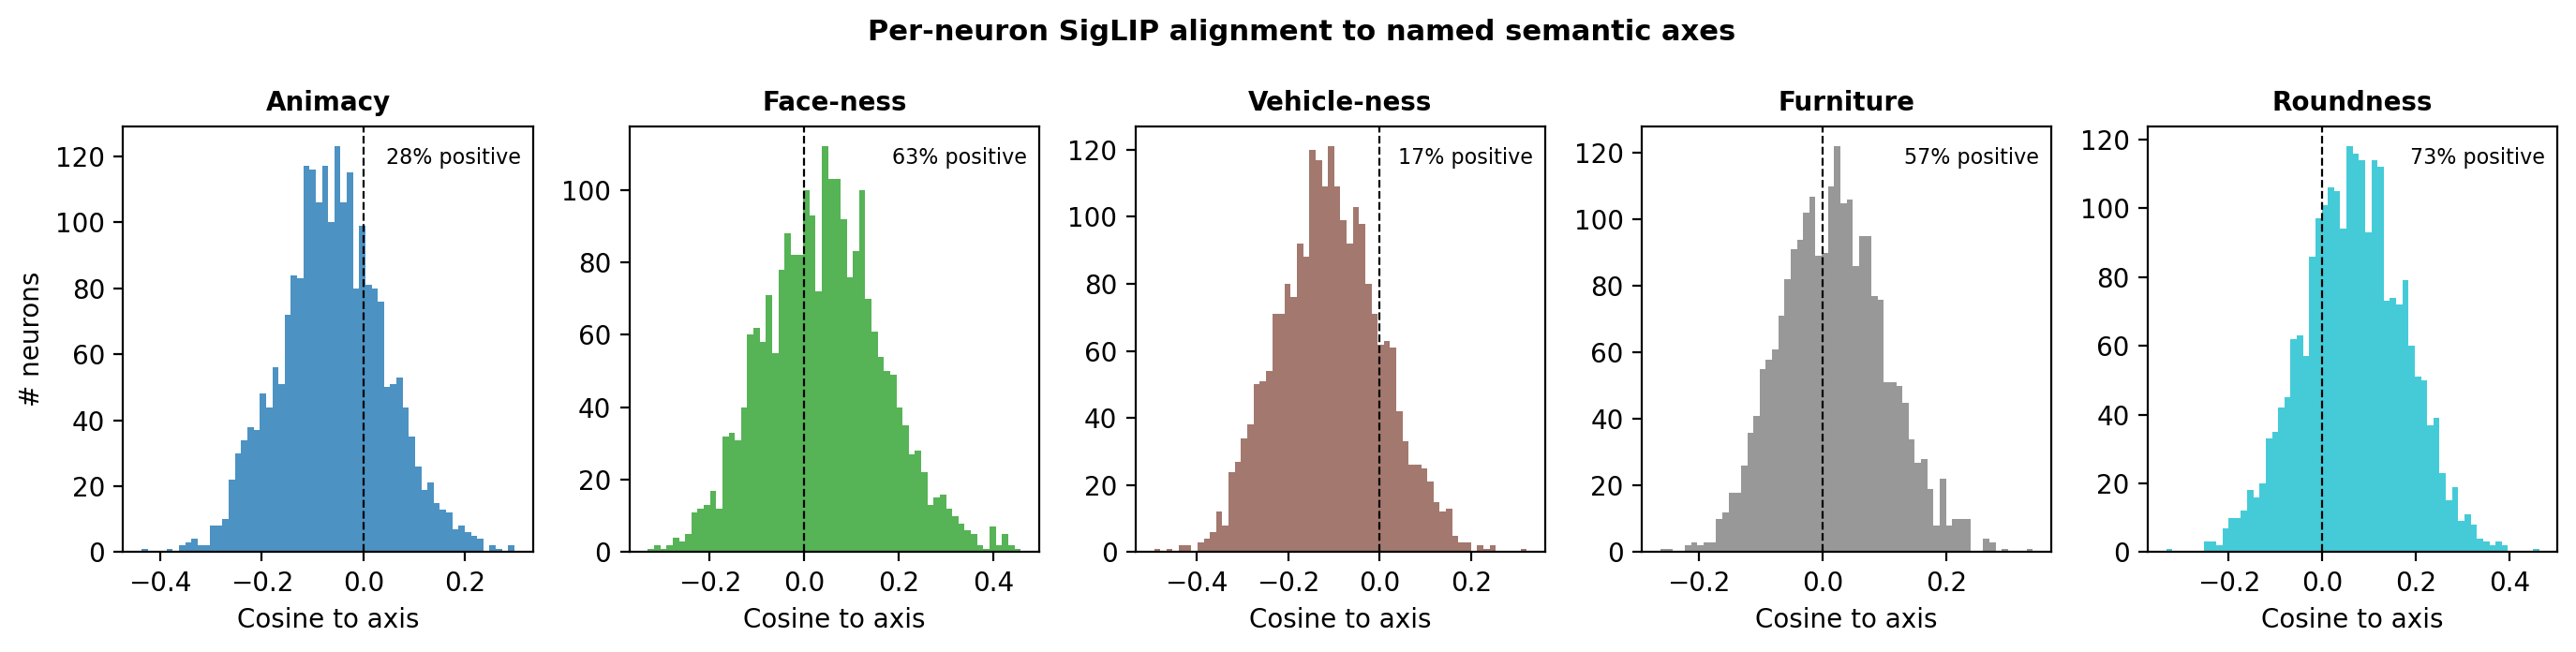

In [7]:
fig, axes_ax = plt.subplots(1, len(AXES), figsize=(14, 3.5), sharey=False)
colors = plt.cm.tab10(np.linspace(0, 1, len(AXES)))

for ax, (name, sc), color in zip(axes_ax, scores.items(), colors):
    ax.hist(sc, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Cosine to axis')
    pct_pos = (sc > 0).mean() * 100
    ax.set_ylabel('# neurons' if ax == axes_ax[0] else '')
    ax.text(0.97, 0.95, f'{pct_pos:.0f}% positive', transform=ax.transAxes,
            ha='right', va='top', fontsize=8)

fig.suptitle('Per-neuron SigLIP alignment to named semantic axes', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Brain-area breakdown

For each brain area, report the mean score on each axis and the fraction of neurons assigned to each axis. This is the "semantic tuning atlas".

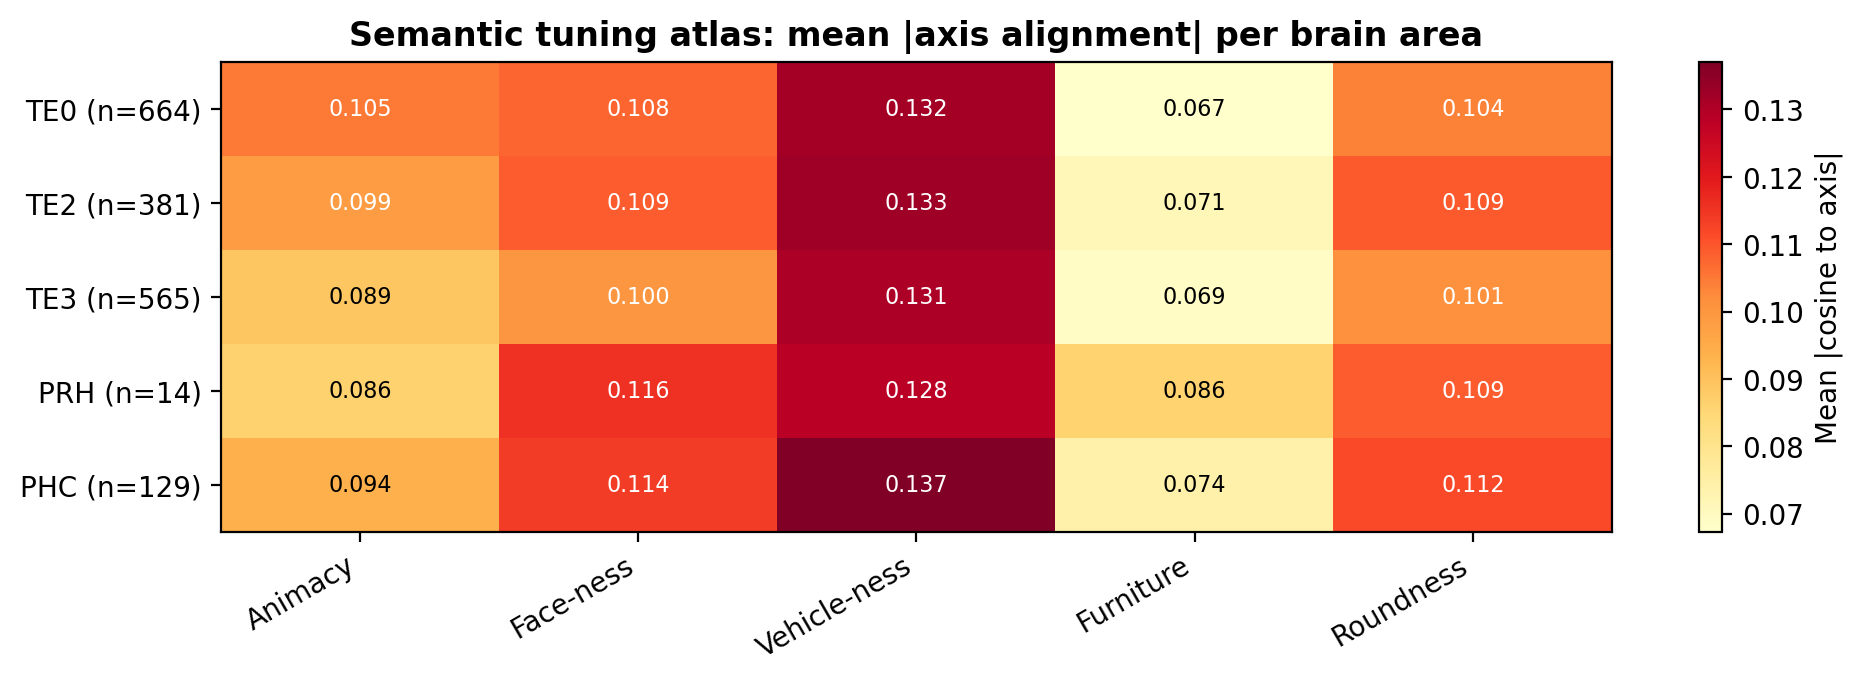

In [8]:
PLOT_AREAS = ['TE0', 'TE2', 'TE3', 'PRH', 'PHC', 'ENT', 'V2', 'V3']
areas_np = np.array(areas)

# Mean |score| per area per axis
area_mean_score = {}  # area -> (n_axes,)
area_n = {}
for a in PLOT_AREAS:
    mask = areas_np == a
    if mask.sum() == 0:
        continue
    area_mean_score[a] = np.abs(score_matrix[mask]).mean(axis=0)
    area_n[a] = mask.sum()

present_areas = [a for a in PLOT_AREAS if a in area_mean_score]
mat = np.stack([area_mean_score[a] for a in present_areas])  # (n_areas, n_axes)

fig, ax = plt.subplots(figsize=(10, max(3, len(present_areas) * 0.7)))
im = ax.imshow(mat, aspect='auto', cmap='YlOrRd')
ax.set_xticks(np.arange(len(axis_names)))
ax.set_xticklabels(axis_names, rotation=30, ha='right', fontsize=10)
ax.set_yticks(np.arange(len(present_areas)))
ax.set_yticklabels([f'{a} (n={area_n[a]})' for a in present_areas], fontsize=10)
plt.colorbar(im, ax=ax, label='Mean |cosine to axis|')
ax.set_title('Semantic tuning atlas: mean |axis alignment| per brain area',
             fontweight='bold')

# Annotate cells
for i in range(len(present_areas)):
    for j in range(len(axis_names)):
        ax.text(j, i, f'{mat[i, j]:.3f}', ha='center', va='center', fontsize=8,
                color='black' if mat[i, j] < mat.max() * 0.7 else 'white')

plt.tight_layout()
plt.show()

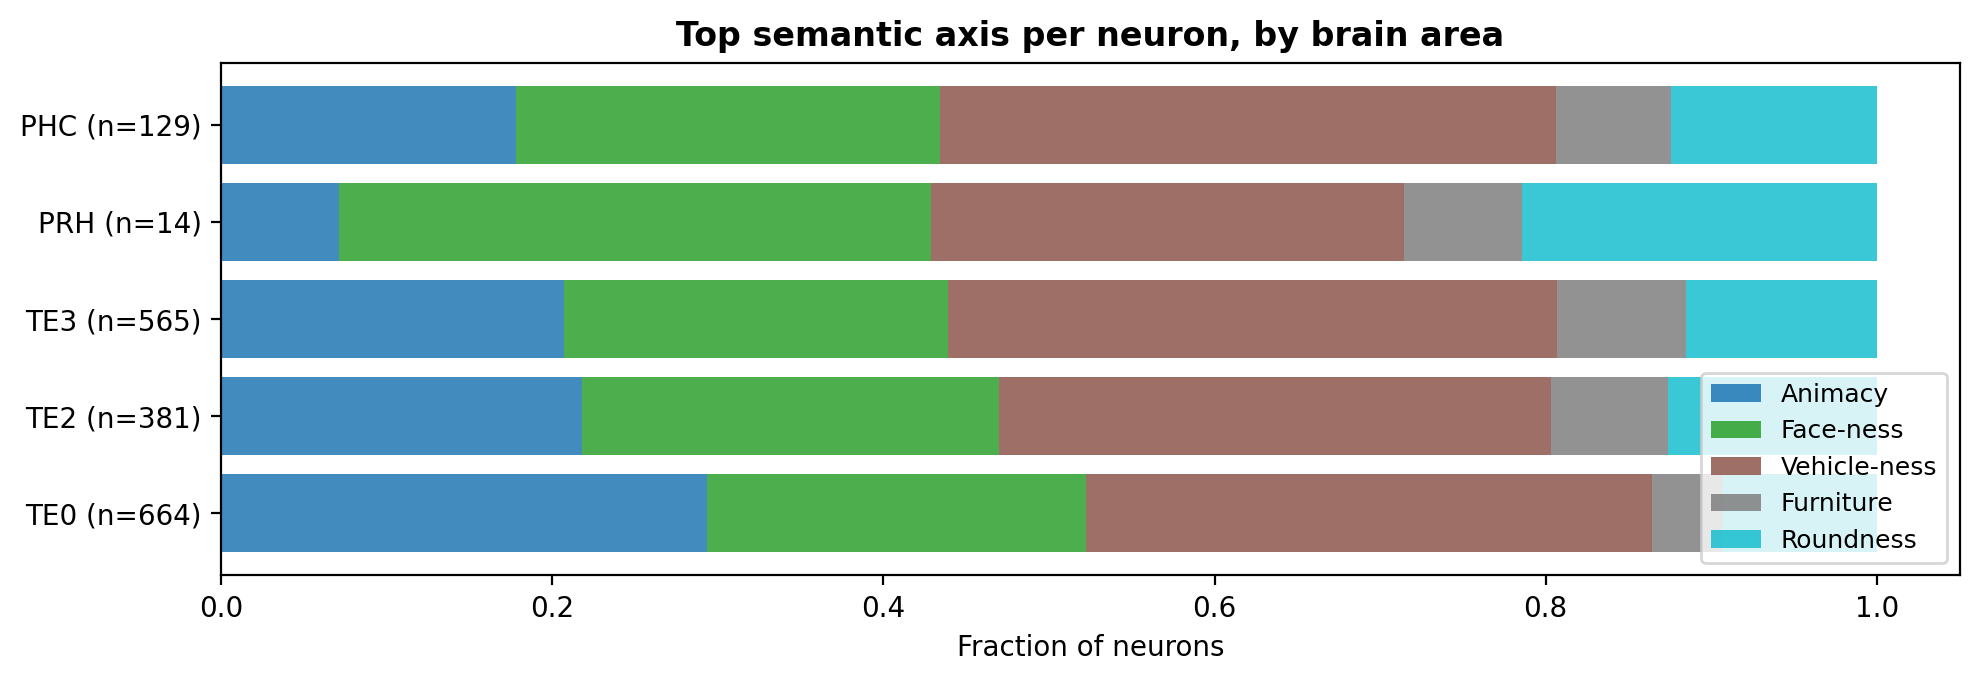

In [9]:
# Stacked bar: fraction of neurons in each area assigned to each top axis
from matplotlib.patches import Patch

axis_colors = dict(zip(axis_names, plt.cm.tab10(np.linspace(0, 1, len(axis_names)))))

fig, ax = plt.subplots(figsize=(10, max(3, len(present_areas) * 0.7)))
y = np.arange(len(present_areas))

lefts = np.zeros(len(present_areas))
for j, aname in enumerate(axis_names):
    fracs = []
    for a in present_areas:
        mask = areas_np == a
        top = np.array(top_axis_labels)[mask]
        fracs.append((top == aname).mean())
    fracs = np.array(fracs)
    ax.barh(y, fracs, left=lefts, color=axis_colors[aname], alpha=0.85, label=aname)
    lefts += fracs

ax.set_yticks(y)
ax.set_yticklabels([f'{a} (n={area_n[a]})' for a in present_areas], fontsize=10)
ax.set_xlabel('Fraction of neurons')
ax.set_title('Top semantic axis per neuron, by brain area', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Top neurons per axis

Report the brain area composition of the top-N most strongly tuned neurons for each axis.

In [10]:
TOP_N = 100

print(f'Top-{TOP_N} neurons per axis — brain area composition:')
for name in axis_names:
    sc = scores[name]
    top_idx = np.argsort(sc)[::-1][:TOP_N]
    top_areas = [areas[i] for i in top_idx]
    area_counts = Counter(top_areas)
    counts_str = '  '.join(f'{a}:{area_counts.get(a,0)}' for a in PLOT_AREAS if area_counts.get(a, 0) > 0)
    print(f'  {name:15s}: {counts_str}')

Top-100 neurons per axis — brain area composition:
  Animacy        : TE0:29  TE2:23  TE3:26  PRH:1  PHC:5
  Face-ness      : TE0:33  TE2:16  TE3:18  PHC:7
  Vehicle-ness   : TE0:38  TE2:13  TE3:24  PHC:2
  Furniture      : TE0:22  TE2:18  TE3:19  PRH:1  PHC:9
  Roundness      : TE0:32  TE2:20  TE3:21  PRH:2  PHC:6
